## Verfahrenswahrscheinlichkeit bei festem $p_0$

Die linke Grafik zeigt Realisationen von $H_n$ auf der
Vertikalen $p=p_0$. Die rechte Grafik zeigt die zugehörigen
Wilson-Konfidenzintervalle. Beide Darstellungen beruhen auf
denselben Stichproben und verbinden damit die Sicht im
$(p,h)$-Raum mit der üblichen Intervallgrafik.

### Eingaben


    Alle veränderbaren Eingaben stehen in der Klasse `Config`.
    Danach folgen getrennt die mathematische Berechnung und die Erzeugung der Grafik.


6 von 50 Wilson-Intervallen enthalten p0=0.27 nicht.


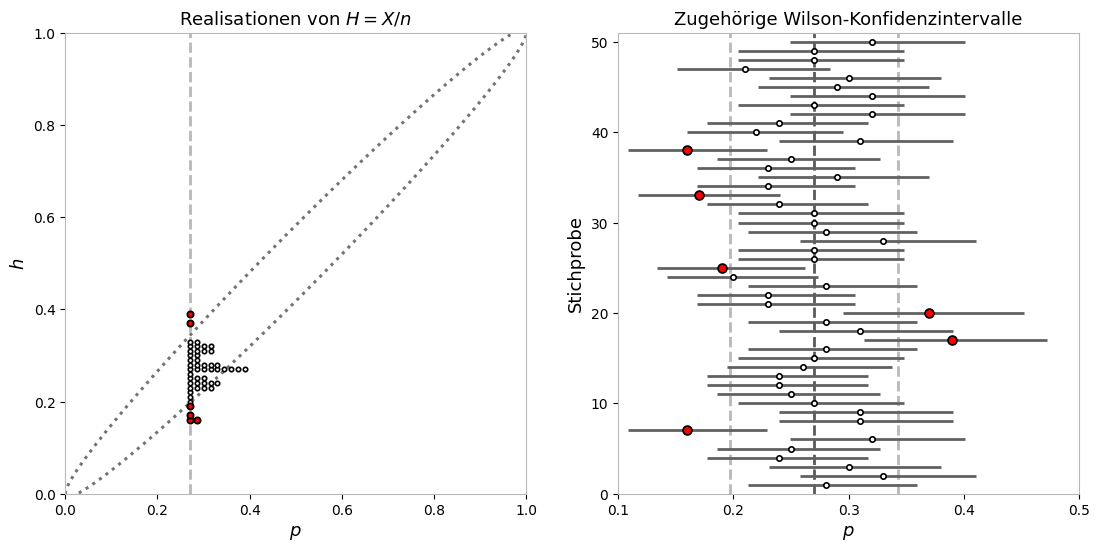

In [1]:
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np

# ============Eingaben =============

@dataclass(frozen=True)
class Parameter:
    n: int = 100
    anzahl_stichproben: int = 50
    p0: float = 0.27
    konfidenzniveau: float = 0.90
    seed: int = 7
    stapelabstand: float = 0.015 # nur Darstellungsabstand

# ========== Berechnungen ===========
def wilson_intervalle(
    treffer: np.ndarray, n: int, z: float
) -> tuple[np.ndarray, np.ndarray]:
    """Wilson-Konfidenzintervalle fuer einen Binomialanteil."""
    h = treffer / n
    nenner = 1 + z**2 / n
    mitte = (h + z**2 / (2 * n)) / nenner
    radius = z / nenner * np.sqrt(
        h * (1 - h) / n + z**2 / (4 * n**2)
    )
    return mitte - radius, mitte + radius

def dotplot_positionen(
    treffer: np.ndarray,
    n: int,
    p0: float,
    stapelabstand: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Gleiche h-Werte werden vom festen p0 aus nach rechts gestapelt."""
    p_punkte: list[float] = []
    h_punkte: list[float] = []

    for k, vielfachheit in sorted(Counter(treffer).items()):
        h_wert = k / n
        p_punkte.extend(
            p0 + stapelabstand * np.arange(vielfachheit)
        )
        h_punkte.extend([h_wert] * vielfachheit)

    return np.asarray(p_punkte), np.asarray(h_punkte)


def zeichne_abbildung(parameter: Parameter) -> tuple[plt.Figure, int]:
    z = NormalDist().inv_cdf((1 + parameter.konfidenzniveau) / 2)

    # Einmal simulieren: Beide Tafeln verwenden exakt dieselben Stichproben.
    rng = np.random.default_rng(parameter.seed)
    treffer = rng.binomial(
        parameter.n, parameter.p0, size=parameter.anzahl_stichproben
    )
    h = treffer / parameter.n

    untergrenze, obergrenze = wilson_intervalle(treffer, parameter.n, z)
    enthaelt_p0 = (untergrenze <= parameter.p0) & (parameter.p0 <= obergrenze)

    # Annahmebereich des Score-Tests bei festem p0.
    prognoseradius = z * np.sqrt(
        parameter.p0 * (1 - parameter.p0) / parameter.n
    )
    h_unten = parameter.p0 - prognoseradius
    h_oben = parameter.p0 + prognoseradius
    im_neymanraum = (h_unten <= h) & (h <= h_oben)

    # Wilson-Intervalle entstehen durch Invertieren desselben Score-Tests.
    assert np.array_equal(enthaelt_p0, im_neymanraum)

    p_punkte, h_punkte = dotplot_positionen(
        treffer,
        parameter.n,
        parameter.p0,
        parameter.stapelabstand,
    )
    punkt_im_neymanraum = (h_unten <= h_punkte) & (h_punkte <= h_oben)

    p = np.linspace(0, 1, 2001)
    radius = z * np.sqrt(p * (1 - p) / parameter.n)

    fig, (ax_links, ax_rechts) = plt.subplots(
        1,
        2,
        figsize=(11.2, 5.4),
        gridspec_kw={"width_ratios": [1, 1.05]},
        constrained_layout=True,
    )

    # Links: Neyman-Raum mit den Realisationen H = X/n.
    ax_links.plot(
        p, p - radius, color="0.45", linestyle=":", linewidth=2.2
    )
    ax_links.plot(
        p, p + radius, color="0.45", linestyle=":", linewidth=2.2
    )
    ax_links.axvline(
        parameter.p0, color="0.72", linestyle="--", linewidth=2
    )
    ax_links.scatter(
        p_punkte[punkt_im_neymanraum],
        h_punkte[punkt_im_neymanraum],
        s=10,
        facecolors="white",
        edgecolors="black",
        linewidths=1.2,
        zorder=3,
    )
    ax_links.scatter(
        p_punkte[~punkt_im_neymanraum],
        h_punkte[~punkt_im_neymanraum],
        s=20,
        facecolors="red",
        edgecolors="black",
        linewidths=1.3,
        zorder=4,
    )
    ax_links.set(
        xlim=(0, 1),
        ylim=(0, 1),
        xlabel=r"$p$",
        ylabel=r"$h$",
        title=r"Realisationen von $H=X/n$",
    )
    ax_links.set_aspect("equal")

    # Rechts: Wilson-Intervalle fuer genau dieselben Stichproben.
    stichprobe = np.arange(1, parameter.anzahl_stichproben + 1)
    ax_rechts.hlines(
        stichprobe,
        untergrenze,
        obergrenze,
        color="0.38",
        linewidth=2.0,
        zorder=1,
    )
    ax_rechts.axvline(
        h_unten, color="0.72", linestyle="--", linewidth=2, zorder=0
    )
    ax_rechts.axvline(
        parameter.p0, color="0.35", linestyle="--", linewidth=2, zorder=0
    )
    ax_rechts.axvline(
        h_oben, color="0.72", linestyle="--", linewidth=2, zorder=0
    )
    ax_rechts.scatter(
        h[enthaelt_p0],
        stichprobe[enthaelt_p0],
        s=15,
        facecolors="white",
        edgecolors="black",
        linewidths=1.2,
        zorder=3,
    )
    ax_rechts.scatter(
        h[~enthaelt_p0],
        stichprobe[~enthaelt_p0],
        s=40,
        facecolors="red",
        edgecolors="black",
        linewidths=1.3,
        zorder=4,
    )
    ax_rechts.set(
        xlim=(0.10, 0.50),
        ylim=(0, parameter.anzahl_stichproben + 1),
        xlabel=r"$p$",
        ylabel="Stichprobe",
        title="Zugehörige Wilson-Konfidenzintervalle",
    )
    ax_rechts.set_xticks(np.arange(0.1, 0.51, 0.1))
    ax_rechts.set_yticks(np.arange(0, parameter.anzahl_stichproben + 1, 10))
    ax_rechts.set_box_aspect(1)

    for ax in (ax_links, ax_rechts):
        for spine in ax.spines.values():
            spine.set_color("0.72")
        ax.tick_params(labelsize=10)
        ax.xaxis.label.set_size(13)
        ax.yaxis.label.set_size(13)
        ax.title.set_size(13)

    return fig, int(np.count_nonzero(~enthaelt_p0))


PARAMETER = Parameter()


if __name__ == "__main__":
    #ausgabeordner = Path(__file__).resolve().parent
    ausgabeordner = Path.cwd()
    abbildung, anzahl_nicht_enthalten = zeichne_abbildung(PARAMETER)

    abbildung.savefig(
        ausgabeordner / "Neymanraum-Wilsonintervalle.pdf",
        bbox_inches="tight",
    )
    abbildung.savefig(
        ausgabeordner / "Neymanraum-Wilsonintervalle.png",
        dpi=300,
        bbox_inches="tight",
    )

    print(
        f"{anzahl_nicht_enthalten} von {PARAMETER.anzahl_stichproben} "
        f"Wilson-Intervallen enthalten p0={PARAMETER.p0} nicht."
    )
    plt.show()
